In [46]:
import pandas as pd

In [47]:
import numpy as np

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("../data/raw/online_retail.csv")

In [50]:
df.shape

(541909, 8)

In [51]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [52]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [53]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [54]:
df['CustomerID'].describe()

count    406829.000000
mean      15287.690570
std        1713.600303
min       12346.000000
25%       13953.000000
50%       15152.000000
75%       16791.000000
max       18287.000000
Name: CustomerID, dtype: float64

In [55]:
df = df.dropna(subset=['CustomerID'])

In [56]:
df= df[df['Quantity']>0]

In [57]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [58]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [59]:
df = df[df['Quantity'] > 0]

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  object 
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  float64
 6   CustomerID   397924 non-null  float64
 7   Country      397924 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


In [61]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
print(df['TotalPrice'])

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalPrice, Length: 397924, dtype: float64


In [63]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [64]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [65]:
print("Total Revenue:", df['TotalPrice'].sum())
print("Total Customers:", df['CustomerID'].nunique())
print("Total Transactions:", df['InvoiceNo'].nunique())

Total Revenue: 8911407.904
Total Customers: 4339
Total Transactions: 18536


In [66]:
df.to_csv("../data/processed/cleaned_online_retail.csv", index=False)

Business Metrics

In [68]:
print("Total Revenue:",df['TotalPrice'].sum())
print("Total Customer:",df['CustomerID'].nunique())
print("Total Transaction:",df['InvoiceNo'].nunique())

Total Revenue: 8911407.904
Total Customer: 4339
Total Transaction: 18536


Country Analysis

In [69]:
top_countries=(
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

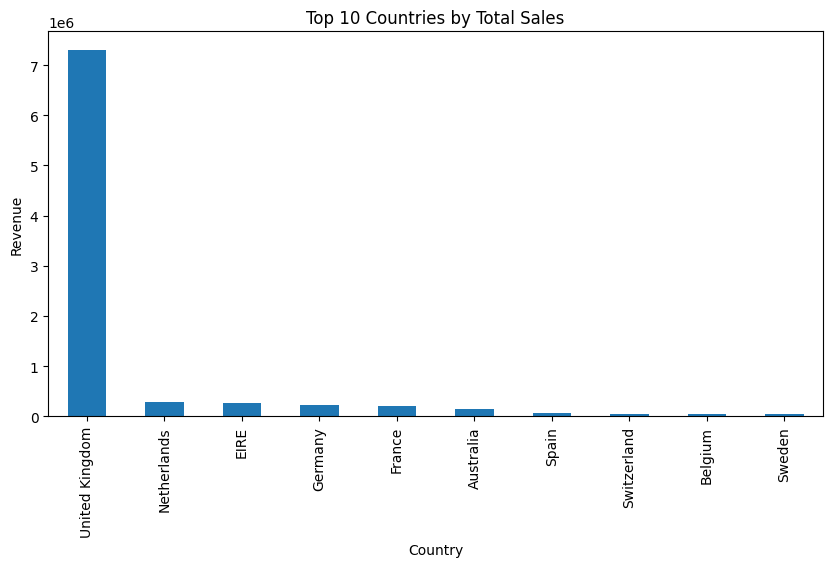

In [70]:
plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()


Monthly Revenue Trend

In [71]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

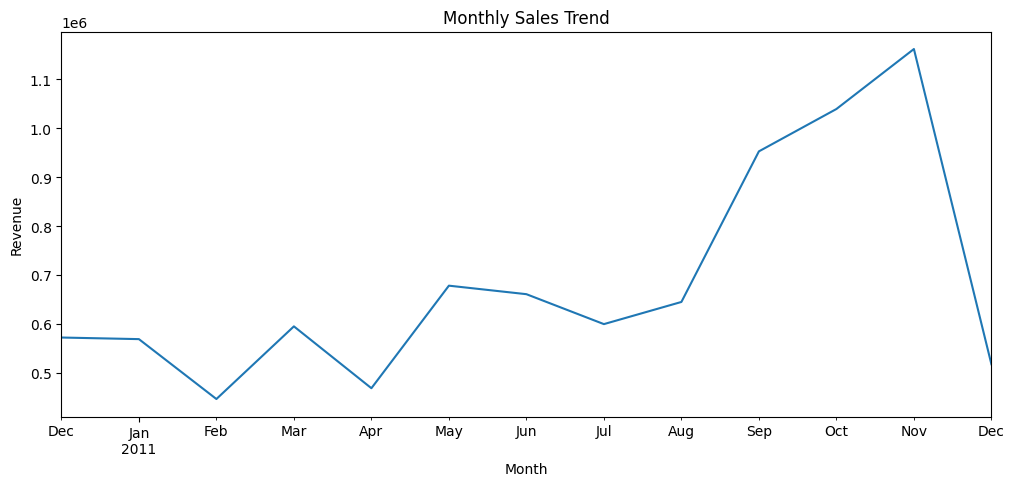

In [72]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

DAY 8 (RFM ANALYSIS)

In [73]:
refernce_date=df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [74]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [75]:

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [76]:
rfm = rfm.reset_index()

In [77]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [78]:
rfm.to_csv("../data/processed/final_rfm_table.csv", index=False)

Create R, F, M Scores

In [83]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                         5,
                         labels=[1,2,3,4,5])

rfm['M_Score'] = pd.qcut(rfm['Monetary'],5,
                        labels=[1,2,3,4,5])

Combine Scores

In [84]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F-Score,M_Score,F_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,1,115
1,12347.0,2,7,4310.00,5,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,4,244
3,12349.0,19,1,1757.55,4,1,4,1,414
4,12350.0,310,1,334.40,1,1,2,1,112


In [85]:
def segment_customer(row):
    
    if row == '555':
        return 'Champions'
    
    elif row[0] == '5':
        return 'Recent Customers'
    
    elif row[1] == '5':
        return 'Loyal Customers'
    
    elif row[2] == '5':
        return 'Big Spenders'
    
    elif row == '111':
        return 'Lost Customers'
    
    else:
        return 'Regular Customers'

# Apply segmentation
rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F-Score,M_Score,F_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,1,115,Big Spenders
1,12347.0,2,7,4310.00,5,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,4,244,Regular Customers
3,12349.0,19,1,1757.55,4,1,4,1,414,Regular Customers
4,12350.0,310,1,334.40,1,1,2,1,112,Regular Customers


In [86]:
rfm['Segment'].value_counts()

Segment
Regular Customers    2679
Recent Customers      520
Loyal Customers       429
Champions             348
Lost Customers        182
Big Spenders          181
Name: count, dtype: int64

**Meaning of Scores
Score	Meaning
High Recency (5)	Recently purchased,
High Frequency (5)	Purchases often,
High Monetary (5)	Spends more money**

In [87]:
rfm.reset_index().head()

,index,CustomerID,Recency,Frequency,Monetary,R_Score,F-Score,M_Score,F_Score,RFM_Score,Segment
0,0,12346.0,326,1,77183.60,1,1,5,1,115,Big Spenders
1,1,12347.0,2,7,4310.00,5,5,5,5,555,Champions
2,2,12348.0,75,4,1797.24,2,4,4,4,244,Regular Customers
3,3,12349.0,19,1,1757.55,4,1,4,1,414,Regular Customers
4,4,12350.0,310,1,334.40,1,1,2,1,112,Regular Customers


Example Segments,
RFM	Segment,
555	Champions,
551	Loyal,
155	Big Spenders,
511	New Customers,
111	Lost Customers,

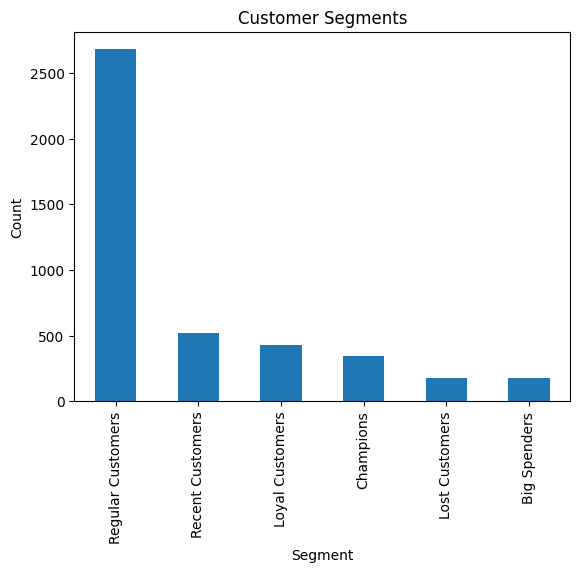

In [88]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')

plt.show()